#### In previous task of data extarction is extarcted the final_extarcted_datd.csv from Adorebooks.in and googleAPIs using python

#### ---After DataExtraction next task is Data cleaning and preprocessing---


In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# now first import the final_extarcted_data.csv
df=pd.read_csv("final_Extracted_data.csv")
df.head()

,Title,Authors,Publisher,Published Date,TextSnippet,ISBN_13,PageCount,Categories,Language,ListPrice,RetailPrice,Title_clean,Current Price,Original Price,Rating
0,Alexander the Great,Martin Howard,Bloomsbury Publishing,2012-05-24,"Alexander the Great, one of the most courageou...",9781408163702,129,Juvenile Nonfiction,en,583.00,291.50,alexander the great,₹95.00,₹150.00,5.0
1,Autobiography of a Yogi,"Paramahansa Yogananda, Sheba Blake",Sheba Blake Publishing,2022-01-10,The famous opera singer Amelita Galli-Curci sa...,9783986770105,645,Biography & Autobiography,en,319.00,223.30,autobiography of a yogi,₹159.00,₹199.00,2.0
2,Be Your Own Sunshine,"James Allen,",Sristhi Publishers & Distributors,2022-02-10,"... <b>own</b> pace, as per <b>our</b> comfort...",9789387022850,114,Self-Help,en,153.40,107.38,be your own sunshine,₹175.00,NaN,4.0
3,Black Holes: The Reith Lectures,Stephen Hawking,Random House,2016-05-05,Stephen Hawking. CLIFFHANGER In my previous <b...,9781473541986,82,Science,en,87.61,87.61,black holes: the reith lectures,₹105.00,₹199.00,3.0
4,Deep and Silent Waters,Charlotte Lamb,Hachette UK,2013-03-28,... <b>silence</b> all evening in a little bar...,9781444770322,353,Fiction,en,350.46,245.32,deep and silent waters,₹169.00,₹599.00,3.0


In [107]:
#now after importing first i have to fix datatypes

df = df.astype({
    "Title_clean": "string",          # normalized title → text
    "Title": "string",                # book title → text
    "Authors": "string",              # authors → text
    "Publisher": "string",            # publisher → text
    "Categories": "string",           # categories → text
    "Language": "string",             # language → text
    "TextSnippet": "string",          # snippet → text
    "ISBN_13": "string",              # ISBN → keep as string (leading zeros matter)
    "PageCount": "Int64",             # page count → integer (nullable)
    "Rating": "float"                 # rating → float
})

# look now befor converting the dataype of price columns we have to fix the ₹RS signs from it so i create a function called clean price
# which return the clean value 
def clean_price(series):
    return (
        series.astype(str)                              # ensure string
        .str.replace(r"[₹Rs\s]", "", regex=True)        # remove ₹, Rs, and spaces
        .str.replace(",", "", regex=True)               # remove commas
        .replace("", None)                              # empty strings → None
        .astype(float)                                  # convert to float
    )

# Apply to price columns
for col in ["Current Price", "Original Price", "ListPrice", "RetailPrice"]:
    if col in df.columns:
        df[col] = clean_price(df[col])


# Convert published date to datetime (handles year-only or full date)
df["Published Date"] = pd.to_datetime(df["Published Date"], errors="coerce")

# Quick check
print(df.dtypes)

Title             string[python]
Authors           string[python]
Publisher         string[python]
Published Date    datetime64[ns]
TextSnippet       string[python]
ISBN_13           string[python]
PageCount                  Int64
Categories        string[python]
Language          string[python]
ListPrice                float64
RetailPrice              float64
Title_clean       string[python]
Current Price            float64
Original Price           float64
Rating                   float64
dtype: object


In [108]:
# now after the type fixing i prefer to change name like i have collected the price from adore and google boh so give desired name to price
df=df.rename(columns={
    "Current Price":"Adore_current_price",
    "Original Price":"Adore_original_price",
    "Published Date":"Date_of_published",
    "Rating":"Adore_rating",
    "ListPrice":"Published_listprice",
    "RetailPrice":"Max_retailprice",
    "TextSnippet":"Short_Description",
    "PageCount":"Total_pages"
})


In [109]:
df.head()

,Title,Authors,Publisher,Date_of_published,Short_Description,ISBN_13,Total_pages,Categories,Language,Published_listprice,Max_retailprice,Title_clean,Adore_current_price,Adore_original_price,Adore_rating
0,Alexander the Great,Martin Howard,Bloomsbury Publishing,2012-05-24,"Alexander the Great, one of the most courageou...",9781408163702,129,Juvenile Nonfiction,en,583.00,291.50,alexander the great,95.0,150.0,5.0
1,Autobiography of a Yogi,"Paramahansa Yogananda, Sheba Blake",Sheba Blake Publishing,2022-01-10,The famous opera singer Amelita Galli-Curci sa...,9783986770105,645,Biography & Autobiography,en,319.00,223.30,autobiography of a yogi,159.0,199.0,2.0
2,Be Your Own Sunshine,"James Allen,",Sristhi Publishers & Distributors,2022-02-10,"... <b>own</b> pace, as per <b>our</b> comfort...",9789387022850,114,Self-Help,en,153.40,107.38,be your own sunshine,175.0,NaN,4.0
3,Black Holes: The Reith Lectures,Stephen Hawking,Random House,2016-05-05,Stephen Hawking. CLIFFHANGER In my previous <b...,9781473541986,82,Science,en,87.61,87.61,black holes: the reith lectures,105.0,199.0,3.0
4,Deep and Silent Waters,Charlotte Lamb,Hachette UK,2013-03-28,... <b>silence</b> all evening in a little bar...,9781444770322,353,Fiction,en,350.46,245.32,deep and silent waters,169.0,599.0,3.0


In [110]:
# Remove HTML tags if any remain
df["Short_Description"] = df["Short_Description"].str.replace(r"<.*?>", "", regex=True)

# Replace HTML entities like &nbsp; with space
df["Short_Description"] = df["Short_Description"].str.replace("&nbsp;", " ", regex=True)

# Strip extra whitespace
df["Short_Description"] = df["Short_Description"].str.strip()

In [111]:
print(df.shape)

(2462, 15)


In [112]:
# Count total NaN values in each column
print(df.isna().sum())

# So as per this i use max retail price when there is (N\A) as when there is no current and orignal we assume that the book sold on max retail price
# Fill NaN in Adore_current_price with Max_retailprice
df["Adore_current_price"] = df["Adore_current_price"].fillna(df["Max_retailprice"])

# Fill NaN in Adore_original_price with Max_retailprice
df["Adore_original_price"] = df["Adore_original_price"].fillna(df["Max_retailprice"])

# Quick check
print(df[["Max_retailprice", "Adore_current_price", "Adore_original_price"]].head())


Title                      0
Authors                    0
Publisher                  0
Date_of_published         57
Short_Description          0
ISBN_13                    0
Total_pages                0
Categories                 0
Language                   0
Published_listprice        0
Max_retailprice            0
Title_clean               12
Adore_current_price     1857
Adore_original_price    1864
Adore_rating            1857
dtype: int64
   Max_retailprice  Adore_current_price  Adore_original_price
0           291.50                 95.0                150.00
1           223.30                159.0                199.00
2           107.38                175.0                107.38
3            87.61                105.0                199.00
4           245.32                169.0                599.00


In [113]:
#Now to fix the rating i prefer to give rating by random but it lead to wrong decisions so i prefer
# to first use the authors average rating then give the book that but when there is stil N/A values 
# i use second catgories vise books rating mean and give to books and then if still N/A
# i use median of Adore rating 

# Fill with author average
df["Adore_rating"] = df["Adore_rating"].fillna(df.groupby("Authors")["Adore_rating"].transform("mean"))

# If still NaN, fill with category average
df["Adore_rating"] = df["Adore_rating"].fillna(df.groupby("Categories")["Adore_rating"].transform("mean"))

# If still NaN, fill with overall median
df["Adore_rating"] = df["Adore_rating"].fillna(df["Adore_rating"].median())

In [114]:
#Dropiing Title clean because we have one column of the Title that is more accurate than Title clean.
#i use the Title clean just to merge both dataframe while extarcting
# Drop Title_clean column
df = df.drop(columns=["Title_clean"])

In [115]:
#now give desired name to language to easily understand  
print(df["Language"].unique())
# Define mapping dictionary
lang_map = {
    "en": "English",
    "hi": "Hindi",
    "de": "German",
    "it": "Italian",
    "gu": "Gujarati",
    "mr": "Marathi",
    "ta": "Tamil",
    "hu": "Hungarian",
    "id": "Indonesian",
    "te": "Telugu",
    "cs": "Czech",
    "kn": "Kannada",
    "pl": "Polish",
    "es": "Spanish",
    "sv": "Swedish"
}

# Apply mapping to the column
df["Language"] = df["Language"].map(lang_map)

# Quick check
print(df["Language"].unique())

<StringArray>
['en', 'hi', 'de', 'it', 'gu', 'mr', 'ta', 'hu', 'id', 'te', 'cs', 'kn', 'pl',
 'es', 'sv']
Length: 15, dtype: string
['English' 'Hindi' 'German' 'Italian' 'Gujarati' 'Marathi' 'Tamil'
 'Hungarian' 'Indonesian' 'Telugu' 'Czech' 'Kannada' 'Polish' 'Spanish'
 'Swedish']


In [116]:
df.head()

,Title,Authors,Publisher,Date_of_published,Short_Description,ISBN_13,Total_pages,Categories,Language,Published_listprice,Max_retailprice,Adore_current_price,Adore_original_price,Adore_rating
0,Alexander the Great,Martin Howard,Bloomsbury Publishing,2012-05-24,"Alexander the Great, one of the most courageou...",9781408163702,129,Juvenile Nonfiction,English,583.00,291.50,95.0,150.00,5.0
1,Autobiography of a Yogi,"Paramahansa Yogananda, Sheba Blake",Sheba Blake Publishing,2022-01-10,The famous opera singer Amelita Galli-Curci sa...,9783986770105,645,Biography & Autobiography,English,319.00,223.30,159.0,199.00,2.0
2,Be Your Own Sunshine,"James Allen,",Sristhi Publishers & Distributors,2022-02-10,"... own pace, as per our comfort? What happens...",9789387022850,114,Self-Help,English,153.40,107.38,175.0,107.38,4.0
3,Black Holes: The Reith Lectures,Stephen Hawking,Random House,2016-05-05,Stephen Hawking. CLIFFHANGER In my previous le...,9781473541986,82,Science,English,87.61,87.61,105.0,199.00,3.0
4,Deep and Silent Waters,Charlotte Lamb,Hachette UK,2013-03-28,... silence all evening in a little bar along ...,9781444770322,353,Fiction,English,350.46,245.32,169.0,599.00,3.0


In [117]:
#print(df.isna().sum())
#print(df.shape)
# As now date of published has N\a values so i think i have to drop the record that have N/A as the record having na is not very large
print(df.isna().sum())
df = df.dropna(subset=["Date_of_published"])

Title                    0
Authors                  0
Publisher                0
Date_of_published       57
Short_Description        0
ISBN_13                  0
Total_pages              0
Categories               0
Language                 0
Published_listprice      0
Max_retailprice          0
Adore_current_price      0
Adore_original_price     0
Adore_rating             0
dtype: int64


In [118]:
print("Total row and column:",df.shape,"\n") 
print(df.info(),"\n")
df.describe()

Total row and column: (2405, 14) 

<class 'pandas.core.frame.DataFrame'>
Index: 2405 entries, 0 to 2461
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Title                 2405 non-null   string        
 1   Authors               2405 non-null   string        
 2   Publisher             2405 non-null   string        
 3   Date_of_published     2405 non-null   datetime64[ns]
 4   Short_Description     2405 non-null   string        
 5   ISBN_13               2405 non-null   string        
 6   Total_pages           2405 non-null   Int64         
 7   Categories            2405 non-null   string        
 8   Language              2405 non-null   object        
 9   Published_listprice   2405 non-null   float64       
 10  Max_retailprice       2405 non-null   float64       
 11  Adore_current_price   2405 non-null   float64       
 12  Adore_original_price  2405 non-null   float64 

,Date_of_published,Total_pages,Published_listprice,Max_retailprice,Adore_current_price,Adore_original_price,Adore_rating
count,2405,2405.0,2405.000000,2405.000000,2405.000000,2405.000000,2405.000000
mean,2019-01-30 03:34:57.130977024,339.164657,883.333522,639.285842,590.878486,717.766495,3.176192
min,1972-12-31 00:00:00,9.0,17.700000,17.700000,17.700000,17.700000,1.000000
25%,2015-11-23 00:00:00,198.0,399.000000,260.190000,209.300000,265.060000,2.952381
50%,2020-10-29 00:00:00,296.0,618.610000,324.500000,289.000000,392.770000,3.229508
75%,2023-07-14 00:00:00,394.0,1003.260000,519.390000,449.000000,599.000000,3.439988
max,2026-03-03 00:00:00,3181.0,22439.470000,22439.470000,22439.470000,22439.470000,5.000000
std,NaN,304.473409,1183.654752,1213.480514,1180.557175,1204.586889,0.906057


In [119]:
df.to_csv("cleaned_data.csv", index=False)

#### ---Now data is cleaned for EXPLORATORY DATA ANALYSIS (EDA)---

In [120]:
# for Summary Statistics
df.describe()

,Date_of_published,Total_pages,Published_listprice,Max_retailprice,Adore_current_price,Adore_original_price,Adore_rating
count,2405,2405.0,2405.000000,2405.000000,2405.000000,2405.000000,2405.000000
mean,2019-01-30 03:34:57.130977024,339.164657,883.333522,639.285842,590.878486,717.766495,3.176192
min,1972-12-31 00:00:00,9.0,17.700000,17.700000,17.700000,17.700000,1.000000
25%,2015-11-23 00:00:00,198.0,399.000000,260.190000,209.300000,265.060000,2.952381
50%,2020-10-29 00:00:00,296.0,618.610000,324.500000,289.000000,392.770000,3.229508
75%,2023-07-14 00:00:00,394.0,1003.260000,519.390000,449.000000,599.000000,3.439988
max,2026-03-03 00:00:00,3181.0,22439.470000,22439.470000,22439.470000,22439.470000,5.000000
std,NaN,304.473409,1183.654752,1213.480514,1180.557175,1204.586889,0.906057


In [121]:
# now using the adore orignal and current price is get the discounted value percentage
df["Adore_discount_value"] = df["Adore_original_price"] - df["Adore_current_price"]
df["Adore_discount_pct"] = ((df["Adore_original_price"] - df["Adore_current_price"]) / df["Adore_original_price"]) * 100
df["Adore_discount_pct"] = df["Adore_discount_pct"].round()

In [122]:
# now using the date of published i calculate the books age = current_year - Year
from datetime import datetime
# year of published
df["Published_year"] = df["Date_of_published"].dt.year
# current year 
Current_year=datetime.now().year
df["Books_age"]=Current_year - df["Published_year"]


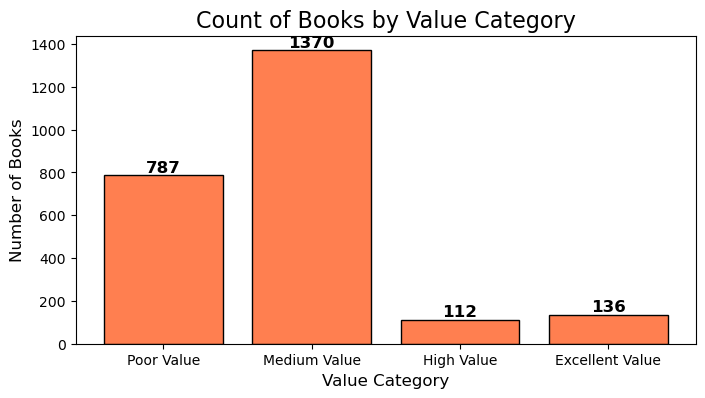

In [123]:
#now i calculated the Value_score that combine both the quality of a book (measured by its rating) and its affordability (measured by discount percentage). 
#This metric helps identify books that provide the best overall value to readers
# - poor Value((-10)-3) → low rating and/or low discount. In this -10 to 3 because some books are seling above then price or expensive because of popularity
# -- Medium Value(3-5) → decent rating or moderate discount.
# --- High Value(5-7) → strong rating and/or big discount.
# ---- Excellent Value(7-10) → best deals: high rating and high discount.

# Then calculate value score
df["Value_score"] = df["Adore_rating"] * (1 + df["Adore_discount_pct"]/100)
# round for readability
df["Value_score"] = df["Value_score"].round(1)
# Categorize value score into bins
df["Value_category"] = pd.cut(
    df["Value_score"],
    bins=[-10, 3, 5, 7, 10],   # extended lower bound to capture negative discounts
    labels=["Poor Value", "Medium Value", "High Value", "Excellent Value"]
)

# visualization
import matplotlib.pyplot as plt

# Count books in each Value_category
value_counts = df["Value_category"].value_counts().sort_index()

# Plot bar chart
plt.figure(figsize=(8,4))
bars = plt.bar(value_counts.index, value_counts.values, color="coral", edgecolor="black")

# Add counts on top of each bar
for bar, count in zip(bars, value_counts.values):
    plt.text( bar.get_x() + bar.get_width()/2, bar.get_height(),str(count),
             ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.title("Count of Books by Value Category", fontsize=16)
plt.xlabel("Value Category", fontsize=12)
plt.ylabel("Number of Books", fontsize=12)
plt.show()

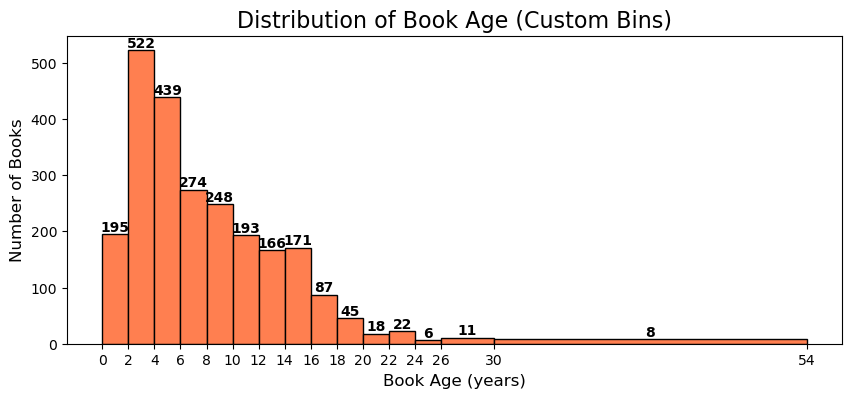

In [124]:
import matplotlib.pyplot as plt

# Drop missing values
book_ages = df["Books_age"].dropna()

# Define custom bins (0–2, 3–5, 6–10, 11–20, 21+)
bins = [0, 2, 4, 6, 8,10,12,14,16,18,20,22,24,26,30, book_ages.max()]

# Create histogram
plt.figure(figsize=(10,4))
counts, bins_edges, patches = plt.hist(book_ages, bins=bins, color="coral", edgecolor="black")

# Add labels on top of bars
for count, left, right in zip(counts, bins_edges[:-1], bins_edges[1:]):
    if count > 0:
        plt.text((left + right)/2, count, str(int(count)),
                 ha="center", va="bottom", fontsize=10, fontweight="bold")

# Titles and labels
plt.title("Distribution of Book Age (Custom Bins)", fontsize=16)
plt.xlabel("Book Age (years)", fontsize=12)
plt.ylabel("Number of Books", fontsize=12)
plt.xticks(bins_edges)  # show bin edges clearly
plt.show()

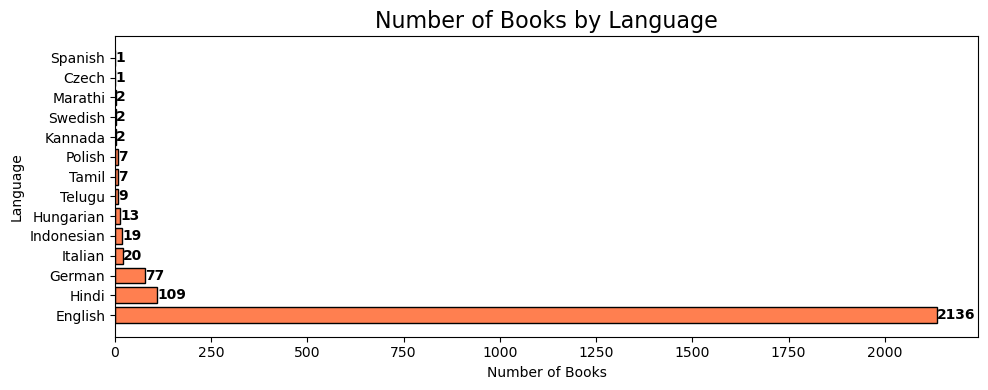

In [125]:
import matplotlib.pyplot as plt

# Count number of books per language
language_counts = df['Language'].value_counts()

# Create horizontal bar chart
plt.figure(figsize=(10,4))
bars = plt.barh(language_counts.index, language_counts.values, 
                color="coral", edgecolor="black")

# Add labels on bars
for bar, count in zip(bars, language_counts.values):
    plt.text(count + 0.5, bar.get_y() + bar.get_height()/2, str(count),
             va="center", fontsize=10, fontweight="bold")

# Titles and labels
plt.title("Number of Books by Language", fontsize=16)
plt.xlabel("Number of Books")
plt.ylabel("Language")
plt.tight_layout()
plt.show()

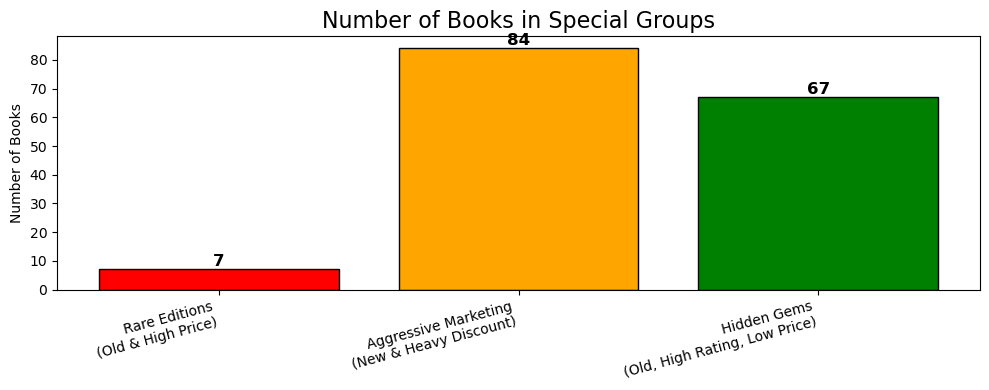

In [126]:
import matplotlib.pyplot as plt

# Define the groups
old_high_price = df[(df["Books_age"] > 3) & (df["Adore_current_price"] > df["Adore_original_price"])]
new_heavy_discount = df[(df["Books_age"] <= 3) & (df["Adore_discount_pct"] > 40)]
old_hidden_gems = df[(df["Books_age"] > 4) & (df["Adore_rating"] >= 4.5) & 
                     (df["Adore_current_price"] < df["Adore_original_price"])]

# Prepare counts
group_counts = {
    "Rare Editions\n(Old & High Price)": len(old_high_price),
    "Aggressive Marketing\n(New & Heavy Discount)": len(new_heavy_discount),
    "Hidden Gems\n(Old, High Rating, Low Price)": len(old_hidden_gems)
}

# Plot bar chart
plt.figure(figsize=(10,4))
bars = plt.bar(group_counts.keys(), group_counts.values(),
               color=["red","orange","green"], edgecolor="black")

# Add labels on top of bars
for bar, count in zip(bars, group_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(count),
             ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.title("Number of Books in Special Groups", fontsize=16)
plt.ylabel("Number of Books")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

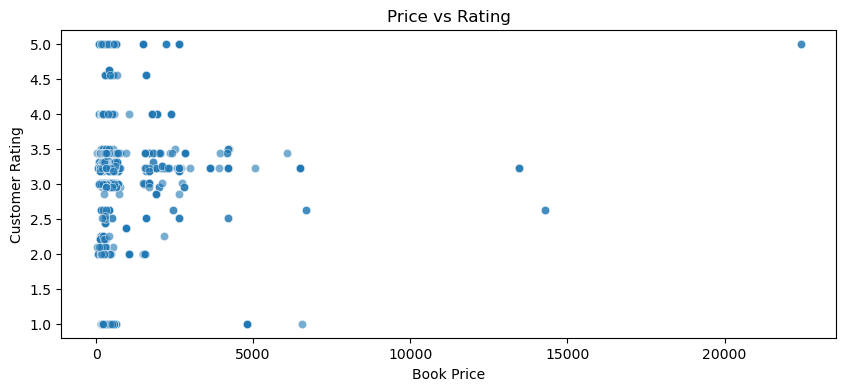

Correlation between price and rating: 0.0077191655231895135


In [127]:

import matplotlib.pyplot as plt
import seaborn as sns
# Problem: Is there a relationship between price and rating?
plt.figure(figsize=(10,4))
sns.scatterplot(data=df, x="Adore_current_price", y="Adore_rating", alpha=0.6)
plt.title("Price vs Rating")
plt.xlabel("Book Price")
plt.ylabel("Customer Rating")
plt.show()

# Calculate correlation
corr = df['Adore_current_price'].corr(df['Adore_rating'])
print("Correlation between price and rating:", corr)

# Solution/Insight:
# If correlation is weak or negative, it shows higher prices don't guarantee better ratings.
# This insight can help adjust pricing strategy or highlight categories where value perception is poor.


##### So this shows almost no correlation between price and customer ratings. This means that higher prices are not translating into higher satisfaction, and customers do not perceive expensive books as offering more value. To address this, the business should shift toward a value‑based pricing strategy rather than relying on premium markups. Categories with weak rating price alignment should be reviewed, and promotional efforts should focus on content quality, relevance, and customer engagement instead of price positioning. By aligning pricing with perceived value and improving non‑price factors such as category fit and marketing, the store can enhance customer satisfaction while maintaining competitiveness.

C:\Users\Expert Solutions\AppData\Local\Temp\ipykernel_19916\2599644992.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x="Published_year", y="Adore_rating", ci=None, marker="o")


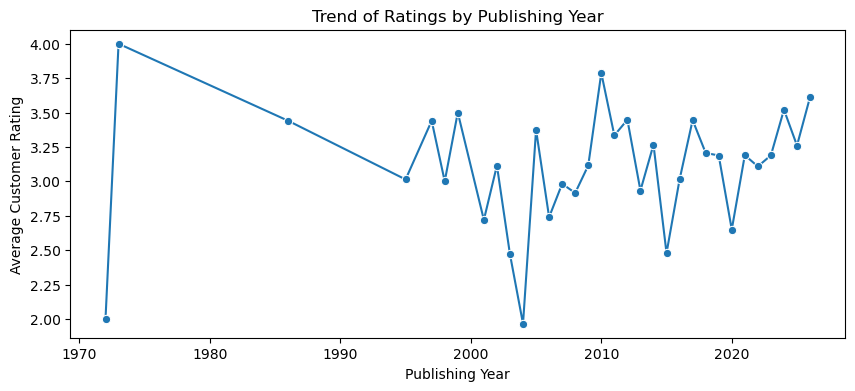

    Published_year  Adore_rating
23            2017      3.444927
24            2018      3.206500
25            2019      3.187617
26            2020      2.650010
27            2021      3.189926
28            2022      3.108220
29            2023      3.189087
30            2024      3.520614
31            2025      3.260102
32            2026      3.612527


In [128]:
# As rating play a vital role in purchasing anything generally people purchase that book which have higher rating and loved by others 
# so Adorebooks website want to know like are newer books consistently rated higher or the older ones?

# Problem: Do ratings improve or decline with publishing year?
plt.figure(figsize=(10,4))
sns.lineplot(data=df, x="Published_year", y="Adore_rating", ci=None, marker="o")
plt.title("Trend of Ratings by Publishing Year")
plt.xlabel("Publishing Year")
plt.ylabel("Average Customer Rating")
plt.show()

# Calculate average rating per year
avg_rating_by_year = df.groupby("Published_year")['Adore_rating'].mean().reset_index()
print(avg_rating_by_year.tail(10))  # Show last 10 years trend

# Insight:
# If the line shows an upward trend, newer books are rated better.
# If downward, older books are valued more.


##### The trend shows that customer ratings fluctuate across decades. Older books (1970s–1980s) were rated more favorably, while books published in the mid‑2000s saw a decline in satisfaction. In recent years (post‑2010), ratings have recovered, suggesting that newer releases are regaining reader approval.so ratings dipped in the mid‑2000s but improved after 2010, publishers should analyze what changed in content, genres, or marketing strategies during those periods. Emphasizing the qualities of newer books that align with reader preferences can sustain the upward trend. At the same time, promoting highly rated older titles as “classics” could attract readers who value proven quality.

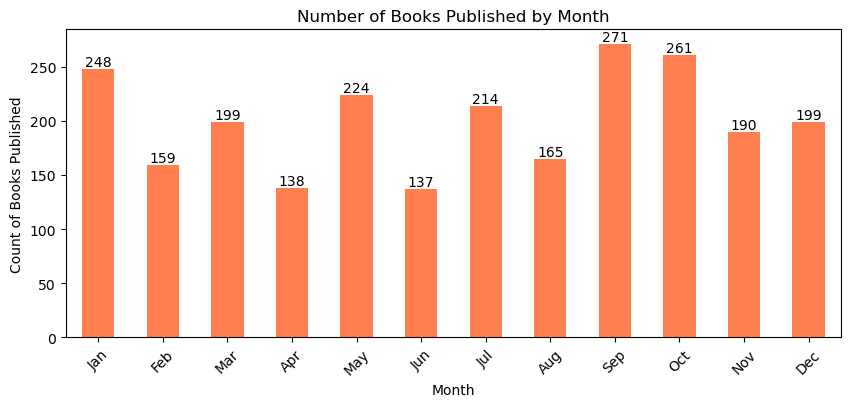

Peak publishing months:
 Publish_month
9    271
Name: count, dtype: int64


In [129]:
#Identifying Seasonal Publishing Trends
#If certain months or seasons consistently see more book releases, publishers and retailers can plan inventory, marketing campaigns, and promotions around those peaks.
#so when peak publishing season adore need to focus on marketing promotion with collaboration with the publisher if one get famous it will lead to massive income.
# Extract month from publishing date/year if available
df['Publish_month'] = pd.to_datetime(df['Date_of_published']).dt.month

# Count number of books published per month
monthly_counts = df['Publish_month'].value_counts().sort_index()
# Visualize
plt.figure(figsize=(10,4))
ax = monthly_counts.plot(kind='bar', color='coral')
plt.title("Number of Books Published by Month")
plt.xlabel("Month")
plt.ylabel("Count of Books Published")
plt.xticks(range(0,12), 
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], 
           rotation=45)
# Add labels on top of each bar
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), 
                (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black')

plt.show()
# Identify peak publishing months
peak_months = monthly_counts[monthly_counts == monthly_counts.max()]
print("Peak publishing months:\n", peak_months)


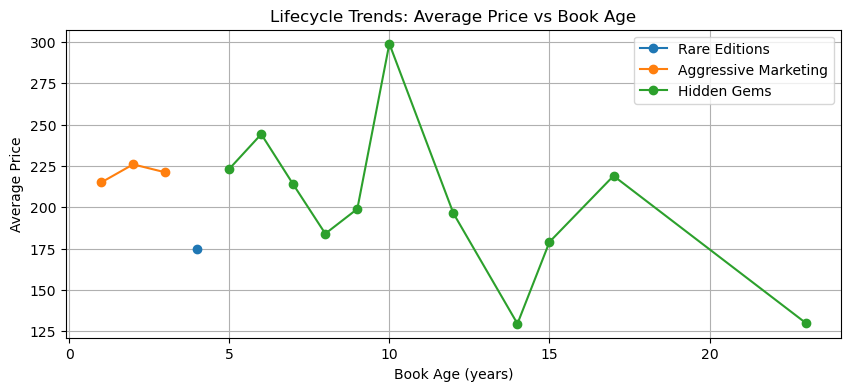

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

for group_name, subset in [("Rare Editions", old_high_price),
                           ("Aggressive Marketing", new_heavy_discount),
                           ("Hidden Gems", old_hidden_gems)]:
    avg_price_by_age = subset.groupby("Books_age")["Adore_current_price"].mean()
    plt.plot(avg_price_by_age.index, avg_price_by_age.values, marker="o", label=group_name)

plt.title("Lifecycle Trends: Average Price vs Book Age")
plt.xlabel("Book Age (years)")
plt.ylabel("Average Price")
plt.legend()
plt.grid(True)
plt.show()

#### ---K-Means Clustering on Book Dataset---
This section applies K-Means clustering to identify natural groupings among books based on age, price, discount, and rating.

In [131]:
print(df.columns)

Index(['Title', 'Authors', 'Publisher', 'Date_of_published',
       'Short_Description', 'ISBN_13', 'Total_pages', 'Categories', 'Language',
       'Published_listprice', 'Max_retailprice', 'Adore_current_price',
       'Adore_original_price', 'Adore_rating', 'Adore_discount_value',
       'Adore_discount_pct', 'Published_year', 'Books_age', 'Value_score',
       'Value_category', 'Publish_month'],
      dtype='object')


                                                  Title       Authors  \
2257                                       Deviant King     Rina Kent   
2209                                       Deviant King     Rina Kent   
748   Heroes of Olympus: The Complete Series (Books ...  Rick Riordan   
1307                                       Deviant King     Rina Kent   
1367  Heroes of Olympus: The Complete Series (Books ...  Rick Riordan   

                                              Publisher Date_of_published  \
2257  Az Ulpius Baráti Kör ajánlásával Művelt Nép Kö...        2024-12-02   
2209  Az Ulpius Baráti Kör ajánlásával Művelt Nép Kö...        2024-12-02   
748                                          Penguin UK        2018-12-13   
1307  Az Ulpius Baráti Kör ajánlásával Művelt Nép Kö...        2024-12-02   
1367                                         Penguin UK        2018-12-13   

                                      Short_Description        ISBN_13  \
2257       A gazfickónak

C:\Users\Expert Solutions\AppData\Local\Temp\ipykernel_19916\3018803483.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


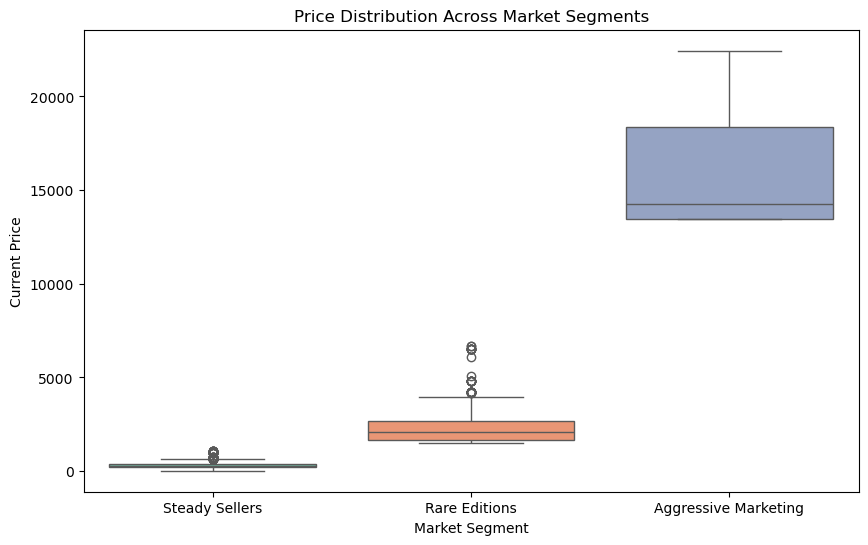

In [132]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Choose features for clustering
features = df[['Adore_current_price', 'Adore_rating', 'Adore_discount_pct']]

# Fit KMeans with 3 clusters (Rare Editions, Steady Sellers, Aggressive Marketing)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(features)

# Map clusters to meaningful labels
cluster_map = {
    0: 'Rare Editions',
    1: 'Steady Sellers',
    2: 'Aggressive Marketing'
}
df['Cluster_label'] = df['Cluster'].map(cluster_map)


def recommend_books(book_id, df, n=5):
    # Find cluster of the target book
    target_cluster = df.loc[book_id, 'Cluster']
    
    # Get other books in same cluster
    cluster_books = df[df['Cluster'] == target_cluster]
    
    # Sort by rating (or discount, etc.)
    recommendations = cluster_books.sort_values('Adore_rating', ascending=False)
    
    # Exclude the target book itself
    recommendations = recommendations.drop(book_id)
    
    return recommendations.head(n)

# Example usage
print(recommend_books(book_id=10, df=df, n=5))

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='Cluster_label',
    y='Adore_current_price',
    palette='Set2'
)

plt.title('Price Distribution Across Market Segments')
plt.xlabel('Market Segment')
plt.ylabel('Current Price')
plt.show()


##### These clusters reveals three distinct market segments--> Rare Editions (small, premium niche), Steady Sellers (large, mainstream group with balanced features), and Aggressive Marketing (discount‑heavy titles). 
##### This segmentation helps explain pricing and promotional strategies --> rare books rely on exclusivity, steady sellers thrive on consistent demand, and aggressively marketed books depend on discounts to drive sales.


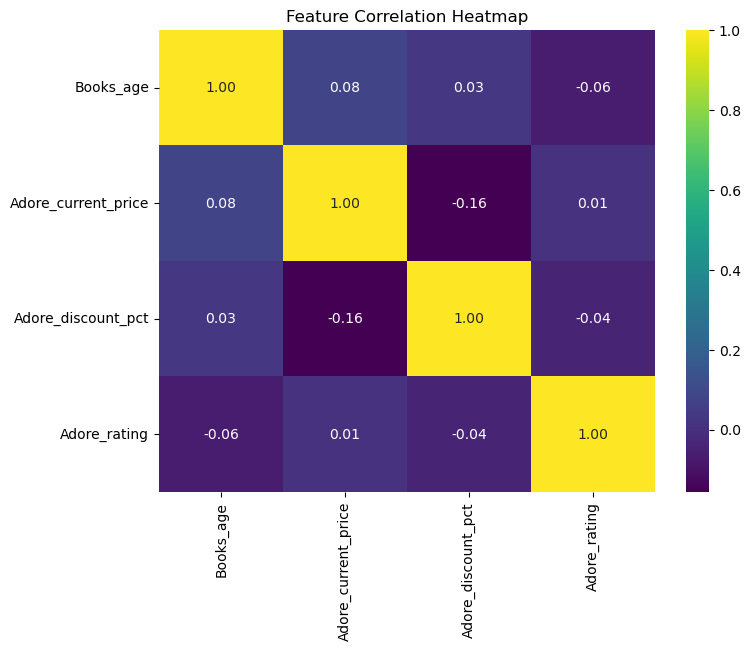

In [133]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = df[['Books_age','Adore_current_price','Adore_discount_pct','Adore_rating']].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='viridis', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

##### So ThIs heatmap shows that most features are only weakly correlated with each other. The strongest relationship is a small negative correlation between price and discount, suggesting that higher‑priced books are less likely to receive large discounts. Other relationships, such as between book age and rating, are negligible, meaning ratings are largely independent of age or price. Overall, the features contribute unique information to clustering, rather than being strongly redundant.





In [134]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Step 2: Define features (X) and target (y)
# X = predictors (independent variables)
# y = target (dependent variable we want to predict)
X = df[['Max_retailprice','Books_age','Adore_discount_pct','Adore_rating']]
y = df['Adore_current_price']

print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())

# Step 3: Split dataset into training and testing sets
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

# Step 4: Train regression model
price_model = LinearRegression()
price_model.fit(X_train, y_train)

print("\nModel trained successfully!")
print("Coefficients (impact of each feature):", price_model.coef_)
print("Intercept (baseline price):", price_model.intercept_)

# Step 5: Predict on test set
y_pred = price_model.predict(X_test)
# Store predictions in the original dataframe
df.loc[y_test.index, "Predicted_price"] = y_pred
print("\nPredicted prices for test set:")
print(y_pred[:5])  # show first 5 predictions

# Step 6: Evaluate accuracy
mse = mean_squared_error(y_test, y_pred)   # Mean Squared Error
rmse = np.sqrt(mse)                        # Root Mean Squared Error

print("\nModel Accuracy:")
print("MSE (Mean Squared Error):", mse)
print("RMSE (Root Mean Squared Error):", rmse)

# Step 7: Predict price for a new book
# Example: Age=5 years, Discount=20%, Rating=3.5
new_book = [[400,5, 0.2, 3.5]]
predicted_price = price_model.predict(new_book)[0]

print("\nPredicted Price for new book (Age=5, Discount=20%, Rating=3.5):", predicted_price)


Features (X):
   Max_retailprice  Books_age  Adore_discount_pct  Adore_rating
0           291.50         14                37.0           5.0
1           223.30          4                20.0           2.0
2           107.38          4               -63.0           4.0
3            87.61         10                47.0           3.0
4           245.32         13                72.0           3.0

Target (y):
0     95.0
1    159.0
2    175.0
3    105.0
4    169.0
Name: Adore_current_price, dtype: float64

Training set size: 1924
Testing set size: 481

Model trained successfully!
Coefficients (impact of each feature): [ 0.90826628 -1.24725004 -3.58552345 13.54974717]
Intercept (baseline price): 24.375412864183318

Predicted prices for test set:
[222.81965865 215.27463658 363.32881007 667.05782743 644.74372473]

Model Accuracy:
MSE (Mean Squared Error): 26394.450145324798
RMSE (Root Mean Squared Error): 162.46368869788967

Predicted Price for new book (Age=5, Discount=20%, Rating=3.5): 428

C:\Users\Expert Solutions\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


##### so as per the output my regression model highlights that ratings and retail price push book prices upward, while discounts and book age reduce them. With an RMSE of ~162, the model is moderately accurate useful for understanding pricing dynamics and guiding decisions, but not yet precise enough for exact price setting. It provides valuable directional insights into how different factors shape book pricing.

### This model help the adore to ist the book at a average price as per the category and according to discounts,rating,max_reatailprice,book age we easily calculate the new price for the book as per the demand of the books  

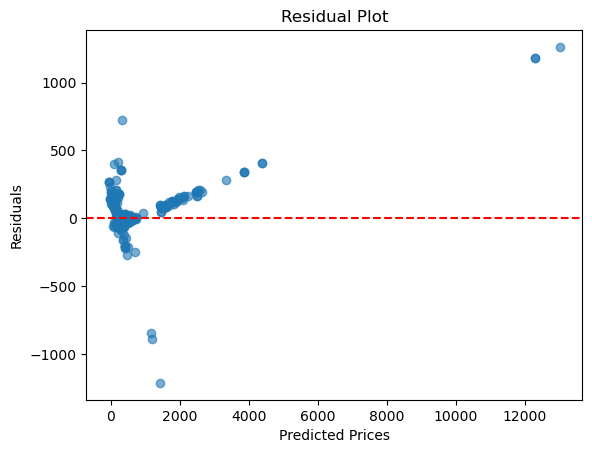

In [135]:
#visualisation
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


### so as per my plot, most points cluster near zero, which is good and shows that my model isn’t systematically "over" or "under" predicting.

In [136]:
print(df.columns)

Index(['Title', 'Authors', 'Publisher', 'Date_of_published',
       'Short_Description', 'ISBN_13', 'Total_pages', 'Categories', 'Language',
       'Published_listprice', 'Max_retailprice', 'Adore_current_price',
       'Adore_original_price', 'Adore_rating', 'Adore_discount_value',
       'Adore_discount_pct', 'Published_year', 'Books_age', 'Value_score',
       'Value_category', 'Publish_month', 'Cluster', 'Cluster_label',
       'Predicted_price'],
      dtype='object')


In [137]:
# Add my predictions and residuals to my DataFrame
df['Predicted_price'] = price_model.predict(X)
df['Residual'] = df['Adore_current_price'] - df['Predicted_price']

# Step 2: Save the DataFrame to a CSV file
df.to_csv("Output.csv", index=False)

print("File saved successfully as output.csv")


File saved successfully as output.csv


##### video Presentation link:


### https://drive.google.com/file/d/1LDnI6Kt_glwsh3oCaUuEx6G3qxz1aEAL/view?usp=sharing